In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

In [ ]:
data = load_wine()
X = data.data
y = data.target
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y
print(df.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target  
0          

In [ ]:
data.feature_names

['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline']

In [ ]:
df.shape

(178, 14)

In [ ]:
print(data.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])


In [ ]:
print(data.target[:])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [ ]:
print(data.data)
print(data.target)
print(data.feature_names)
print(data.target_names)


[[1.423e+01 1.710e+00 2.430e+00 ... 1.040e+00 3.920e+00 1.065e+03]
 [1.320e+01 1.780e+00 2.140e+00 ... 1.050e+00 3.400e+00 1.050e+03]
 [1.316e+01 2.360e+00 2.670e+00 ... 1.030e+00 3.170e+00 1.185e+03]
 ...
 [1.327e+01 4.280e+00 2.260e+00 ... 5.900e-01 1.560e+00 8.350e+02]
 [1.317e+01 2.590e+00 2.370e+00 ... 6.000e-01 1.620e+00 8.400e+02]
 [1.413e+01 4.100e+00 2.740e+00 ... 6.100e-01 1.600e+00 5.600e+02]]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
['class_0' 'class_1'

In [ ]:
print(data.target_names)

['class_0' 'class_1' 'class_2']


In [ ]:
X = df.drop('target', axis=1)
y = df['target']

In [ ]:
print("\nTarget Class Distribution :\n",df['target'].value_counts())


Target Class Distribution :
 target
1    71
0    59
2    48
Name: count, dtype: int64


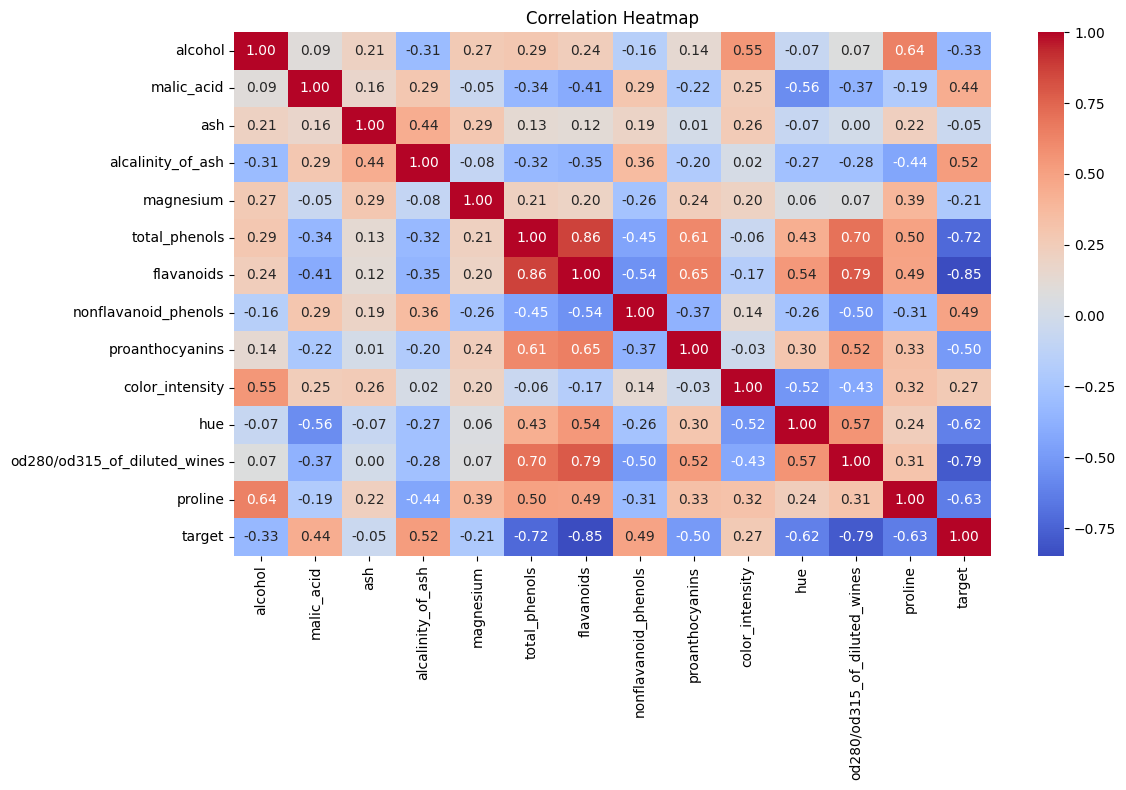

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True,fmt = ".2f",cmap = "coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

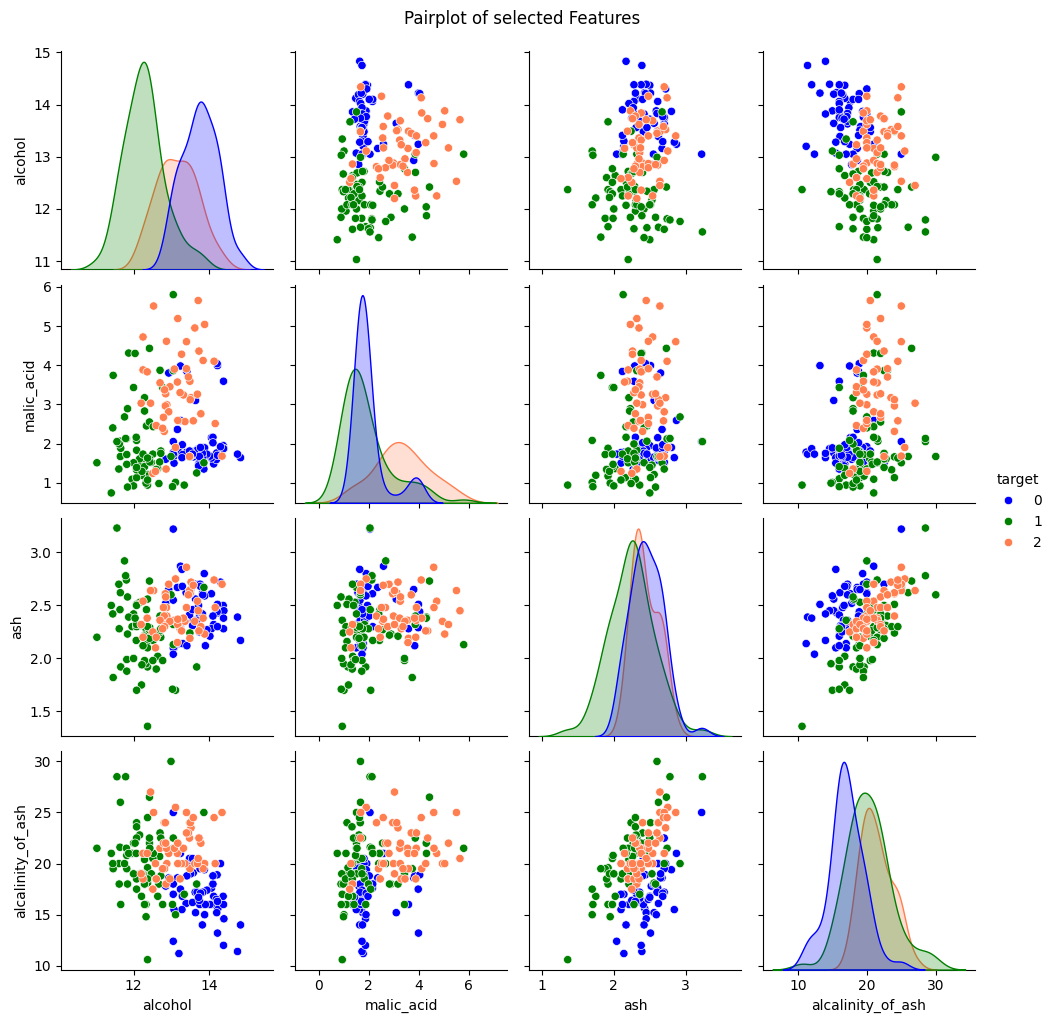

In [ ]:
palette = {
    0: 'blue',
    1: 'green',
    2: 'coral'
}
sns.pairplot(df, vars=data.feature_names[:4],hue='target', palette=palette)
plt.suptitle("Pairplot of selected Features",y=1.02)
plt.show()

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_scaled.shape

(178, 13)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
print("Training data Shape",X_train.shape)
print("Testing data Shape",X_test.shape)
print("Training Labels",y_train.shape)
print("Testing Labels",y_test.shape)

Training data Shape (142, 13)
Testing data Shape (36, 13)
Training Labels (142,)
Testing Labels (36,)


In [ ]:
class KNN :
  def __init__(self, k=3):
    self.k = k

  def fit(self, X, y):
    self.X_train = X
    self.y_train = y.values # Convert y to a numpy array for consistent positional indexing

  def euclidean_diatance(self, x1, x2):
    distance = np.sqrt(np.sum((x1-x2)**2))
    return distance

  def predict_single(self, X):
    distances = []
    for train_sample in self.X_train:
      distance = self.euclidean_diatance(X, train_sample)
      distances.append(distance)

    k_indices = np.argsort(distances)[:self.k]
    k_labels = [self.y_train[i] for i in k_indices] # self.y_train is now a numpy array, so this works
    prediction = Counter(k_labels).most_common(1)[0][0]
    return prediction

  def predict(self, X):
    predictions = []

    for sample in X:
      prediction = self.predict_single(sample)
      predictions.append(prediction)

    return np.array(predictions)

In [ ]:
new_sample = np.array([[13.5,1.8,2.4,16.5,105,
                        2.8,2.9,0.30,1.9,
                        5.2,1.05,3.2,950]])

new_sample_scaled = scaler.transform(new_sample)

knn = KNN(k=5)
knn.fit(X_train, y_train)
prediction = knn.predict(new_sample_scaled)
print("Predicted Class:", prediction[0])
print("Wine Category:",data.target_names[prediction[0]])

Predicted Class: 0
Wine Category: class_0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
knn=KNN(k=5)
knn.fit(X_train,y_train)
y_pred=knn.predict(X_test)

In [ ]:
results = pd.DataFrame({'Actual':y_test.values,'Predicted':y_pred})
print(results.head(15))

    Actual  Predicted
0        0          0
1        0          0
2        2          2
3        0          0
4        1          1
5        0          0
6        1          1
7        2          2
8        1          1
9        2          2
10       0          0
11       2          2
12       0          0
13       1          2
14       0          0


In [ ]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy*100,2),"%")

Accuracy: 94.44 %


In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[14  0  0]
 [ 1 12  1]
 [ 0  0  8]]


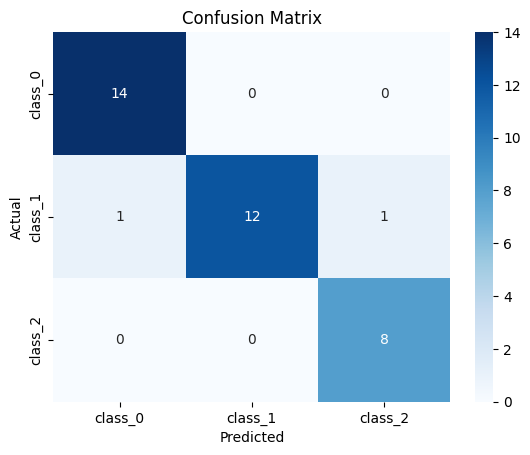

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
for k in [1,3,5,7,9,11,13,15,17]:
  knn = KNN(k=k)
  knn.fit(X_train, y_train)
  y_pred = knn.predict(X_test)
  acc = accuracy_score(y_test, y_pred)
  print(f"k={k} Accuracy = {acc:.4f}")

k=1 Accuracy = 0.9444
k=3 Accuracy = 0.9444
k=5 Accuracy = 0.9444
k=7 Accuracy = 0.9444
k=9 Accuracy = 0.9444
k=11 Accuracy = 0.9444
k=13 Accuracy = 0.9444
k=15 Accuracy = 0.9722
k=17 Accuracy = 0.9722


In [ ]:
for k in [1,3,5,7,9,11,13,15,17] :
  knn = KNN(k=k)
  knn.fit(X_train, y_train)
  y_pred = knn.predict(X_test)
  print(f"\nK={k}")
  print(confusion_matrix(y_test, y_pred))


K=1
[[14  0  0]
 [ 1 12  1]
 [ 0  0  8]]

K=3
[[14  0  0]
 [ 1 12  1]
 [ 0  0  8]]

K=5
[[14  0  0]
 [ 1 12  1]
 [ 0  0  8]]

K=7
[[14  0  0]
 [ 1 12  1]
 [ 0  0  8]]

K=9
[[14  0  0]
 [ 1 12  1]
 [ 0  0  8]]

K=11
[[14  0  0]
 [ 1 12  1]
 [ 0  0  8]]

K=13
[[14  0  0]
 [ 1 12  1]
 [ 0  0  8]]

K=15
[[14  0  0]
 [ 1 13  0]
 [ 0  0  8]]

K=17
[[14  0  0]
 [ 1 13  0]
 [ 0  0  8]]


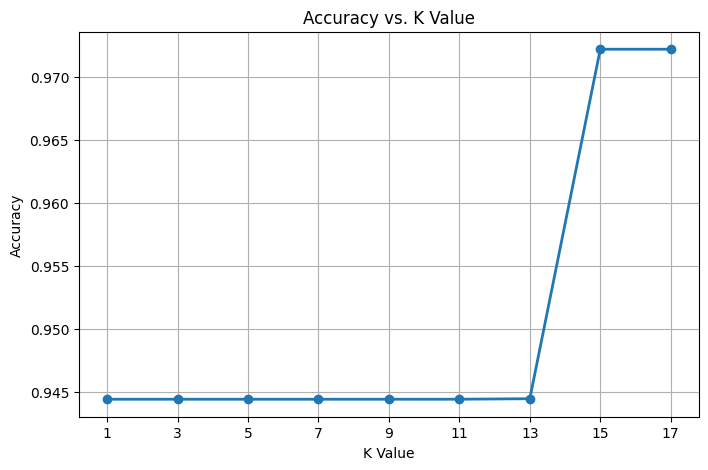

In [ ]:
k_values = [1,3,5,7,9,11,13,15,17]
accuracies = [
    0.9444,0.9444,0.9444,0.9444,0.9444,0.9444,0.94444,0.9722,0.9722
]

plt.figure(figsize=(8,5))
plt.plot(k_values, accuracies, marker='o', linewidth=2)
plt.title('Accuracy vs. K Value')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [ ]:
X_train = np.array([1000,1200,1500,1800,2000])

y_train = np.array([50,60,75,90,100])

class KNNRegression :
  def __init__(self, k=3):
    self.k = k

  def fit(self, X, y):
    self.X_train = X
    self.y_train = y

  def euclidean_diatance(self, x1, x2):
    distance = np.sqrt(np.sum((x1-x2)**2))
    return distance

  def predict_single(self, X):
    distances = []
    for train_sample in self.X_train:
      distance = self.euclidean_diatance(X, train_sample)
      distances.append(distance)

    k_indices = np.argsort(distances)[:self.k]
    k_labels = [self.y_train[i] for i in k_indices]
    prediction = np.mean(k_labels)
    return prediction

  def predict(self, X):
    predictions = []

    for sample in X:
      prediction = self.predict_single(sample)
      predictions.append(prediction)
    return np.array(predictions)


knn = KNNRegression(k=3)
knn.fit(X_train, y_train)


x_test = np.array([1600])
predicted_price = knn.predict(x_test)
print("Predicted Price:", predicted_price[0],"Lakhs")

Predicted Price: 75.0 Lakhs


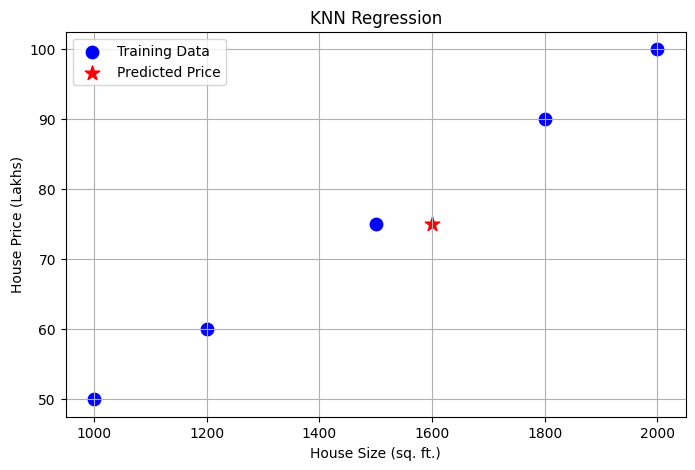

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(X_train, y_train, color='blue',s=80, label='Training Data')
plt.scatter(x_test, predicted_price, color='red',s=120,marker='*', label='Predicted Price')
plt.xlabel("House Size (sq. ft.)")
plt.ylabel("House Price (Lakhs)")
plt.title("KNN Regression")
plt.legend()
plt.grid(True)
plt.show()